<div style="text-align:center">

# Proyecto 1  
## Clasificación de Riesgo Crediticio  

**Machine Learning**  
Universidad del Rosario

Vanessa Ochoa, Nilson Amaya, Juan Zamora

</div>

---

## Tabla de contenido

- [1. Introducción](#1-introducción)
- [2. Importación del dataset](#2-importación-del-dataset)
- [3. Análisis Exploratorio de Datos (EDA)](#3-eda)
- [4. Implementación de Modelos](#4-modelos)
- [5. Optimización de Hiperparámetros y Validación](#5-optimización)
- [6. Métricas de Evaluación y Decisión](#6-métricas)
- [7. Predicción en el conjunto de test](#7-test)


<a id="1-introducción"></a>
## 1. Introducción

El riesgo crediticio es uno de los principales problemas que enfrentan las instituciones financieras, ya que implica la posibilidad de que una persona no cumpla con sus obligaciones de pago. Poder anticipar este tipo de situaciones es clave para reducir pérdidas y mejorar la toma de decisiones.

En este proyecto se utiliza el dataset **"Give Me Some Credit"** con el objetivo de predecir si una persona tendrá dificultades financieras en los próximos dos años. Este problema se aborda como una tarea de **clasificación binaria**, donde el modelo debe identificar si un cliente presenta riesgo de incumplimiento o no.

Para resolver este problema se desarrolla un flujo completo de **Machine Learning**, que incluye:

- Análisis exploratorio de datos (EDA), tratamiento de valores faltantes y outliers.
- Implementación y comparación de modelos de clasificación: **k-NN** y **Regresión Logística**.
- Evaluación del impacto del tipo de escalamiento (**Normalización** vs. **Estandarización**) sobre el desempeño.
- Optimización de hiperparámetros mediante **Grid Search** y **validación cruzada estratificada**.
- Evaluación final con **métricas de clasificación** adecuadas para datos desbalanceados.

Finalmente, se comparan los modelos para identificar cuál ofrece el mejor desempeño en la predicción del riesgo crediticio.

<a id="2-importación-del-dataset"></a>
## 2. Importación del dataset

Antes de cargar el dataset, se importan las librerías necesarias para el desarrollo del proyecto.

In [1]:
########################################################
## LIBRERÍAS                                          ##
########################################################

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Modelado y evaluación
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

A continuación cargamos los archivos `cs-training.csv` y `cs-test.csv` directamente desde Google Colab. La primera columna de ambos archivos es un índice sin nombre que se descarta al momento de la carga.

In [3]:
train = pd.read_csv("../input/cs-training.csv")
test = pd.read_csv("../input/cs-test.csv")
train = train.drop(columns=['Unnamed: 0'])
test = test.drop(columns=['Unnamed: 0'])

# ver primeras filas
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

Revisamos un resumen estadístico de las variables para tener una primera idea de sus rangos, valores extremos y posibles inconsistencias.

In [4]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


### 2.1 Descripción de las variables

- **SeriousDlqin2yrs:** Variable objetivo. Indica si la persona tuvo dificultades financieras graves (atraso ≥ 90 días) en los siguientes dos años. Toma valor 1 (sí incumplió) o 0 (no incumplió).

- **RevolvingUtilizationOfUnsecuredLines:** Proporción del saldo utilizado en tarjetas de crédito y líneas personales respecto al límite total disponible. En condiciones normales se expresa entre 0 y 1.

- **age:** Edad del titular del crédito en años.

- **NumberOfTime30-59DaysPastDueNotWorse:** Número de veces que el prestatario tuvo atrasos entre 30 y 59 días en los últimos dos años.

- **DebtRatio:** Relación entre las obligaciones financieras mensuales y el ingreso bruto mensual.

- **MonthlyIncome:** Ingreso mensual reportado por el prestatario.

- **NumberOfOpenCreditLinesAndLoans:** Número total de préstamos y líneas de crédito abiertas.

- **NumberOfTimes90DaysLate:** Número de veces que el prestatario tuvo atrasos de 90 días o más.

- **NumberRealEstateLoansOrLines:** Número de préstamos hipotecarios o líneas de crédito sobre vivienda.

- **NumberOfTime60-89DaysPastDueNotWorse:** Número de veces que el prestatario tuvo atrasos entre 60 y 89 días en los últimos dos años.

- **NumberOfDependents:** Número de personas que dependen económicamente del prestatario.

<a id="3-eda"></a>
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Identificación y tratamiento de datos faltantes e imputación lógica

Antes de entrenar cualquier modelo es necesario identificar si existen variables con datos ausentes, ya que la mayoría de los algoritmos de Machine Learning no pueden trabajar con valores faltantes directamente.

A continuación identificamos el porcentaje de datos faltantes por variable:

In [5]:
########################################################
## IDENTIFICACIÓN DE VALORES FALTANTES               ##
########################################################

faltantes  = train.isnull().sum()
porcentaje = (faltantes / len(train)) * 100

tabla_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje (%)':    porcentaje.round(2)
})

print(tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0])

                    Valores faltantes  Porcentaje (%)
MonthlyIncome                   29731           19.82
NumberOfDependents               3924            2.62


Se identificaron dos variables con datos ausentes:

- **MonthlyIncome:** presenta 19.82% de valores faltantes. Al analizar estos registros, se observa que las personas con ingreso desconocido tienen una tasa de incumplimiento ligeramente mayor que aquellas con ingreso conocido. Esto sugiere que la ausencia de información no es completamente aleatoria y, por tanto, el hecho de no reportar ingreso también aporta señal predictiva. Por esta razón, antes de realizar la imputación se crea la variable indicadora flag_ingreso_nulo, la cual toma valor 1 cuando el ingreso era originalmente desconocido y 0 en caso contrario.

- **NumberOfDependents:** presenta 2.62% de valores faltantes. Dado que el porcentaje es bajo y no se identificó un patrón diferencial claro frente al incumplimiento, esta variable se imputa directamente con la mediana.

En ambos casos se utiliza la mediana como valor de imputación, y no la media, porque las variables financieras suelen presentar outliers extremos. La media tiende a desplazarse hacia esos valores atípicos, mientras que la mediana, al representar el valor central de la distribución, es mucho más robusta y refleja mejor el comportamiento del cliente típico.

*Regla de oro: los parámetros de imputación, como la mediana, deben calcularse únicamente sobre el conjunto de entrenamiento (train) y luego aplicarse al conjunto de prueba (test) usando exactamente esos mismos valores. Esto evita fuga de información (data leakage) y garantiza una evaluación correcta del modelo.*

In [6]:
########################################################
## IMPUTACIÓN CON MEDIANA                            ##
########################################################

# Crear variable indicadora ANTES de imputar MonthlyIncome
# Registra si el ingreso era desconocido originalmente
train['flag_ingreso_nulo'] = train['MonthlyIncome'].isnull().astype(int)
test['flag_ingreso_nulo']  = test['MonthlyIncome'].isnull().astype(int)

# Calcular medianas sobre el conjunto de entrenamiento
median_monthly_income = train['MonthlyIncome'].median()
median_dependents     = train['NumberOfDependents'].median()

# Imputar en train
train['MonthlyIncome']       = train['MonthlyIncome'].fillna(median_monthly_income)
train['NumberOfDependents']  = train['NumberOfDependents'].fillna(median_dependents)

# Imputar en test con los mismos valores calculados en train
test['MonthlyIncome']        = test['MonthlyIncome'].fillna(median_monthly_income)
test['NumberOfDependents']   = test['NumberOfDependents'].fillna(median_dependents)

# Verificar
print("Faltantes en train después de imputación:", train.isnull().sum().sum())
print("Faltantes en test después de imputación: ", test.isnull().sum().sum())
print(f"\nMediana MonthlyIncome usada:      {median_monthly_income:.2f}")
print(f"Mediana NumberOfDependents usada: {median_dependents:.2f}")

Faltantes en train después de imputación: 0
Faltantes en test después de imputación:  101503

Mediana MonthlyIncome usada:      5400.00
Mediana NumberOfDependents usada: 0.00


### 3.2 Análisis de distribuciones y detección de outliers

Analizamos la forma de las distribuciones con boxplots para identificar valores extremos. A continuación se visualizan las 10 variables numéricas del dataset:

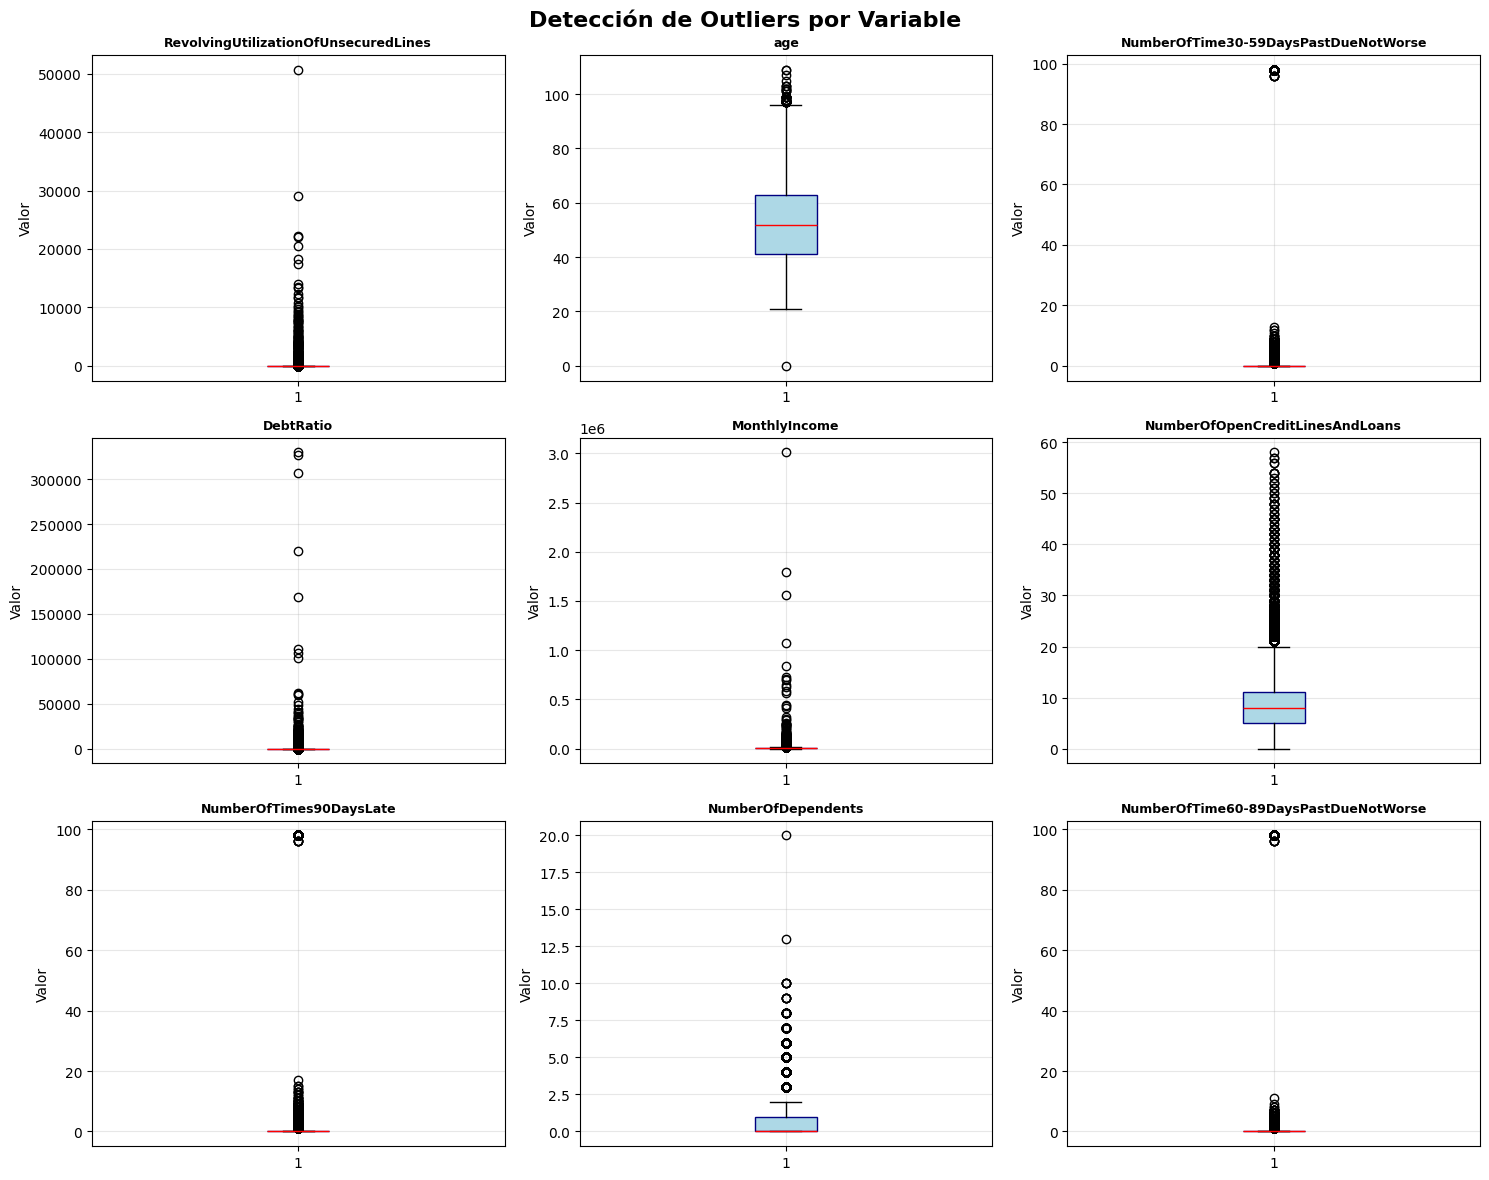

In [8]:
########################################################
## BOXPLOTS — DETECCIÓN DE OUTLIERS                  ##
########################################################

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

columnas = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberOfDependents',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for i, col in enumerate(columnas):
    axes[i].boxplot(train[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red'))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Valor')
    axes[i].grid(alpha=0.3)

fig.suptitle('Detección de Outliers por Variable', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Los boxplots revelan la presencia de valores extremos en varias variables. El tratamiento de cada una se define considerando su **significado financiero**, no simplemente su magnitud:

| Variable | Problema | Decisión | ¿Por qué? |
|---|---|---|---|
| `RevolvingUtilization` | Máximo = 50,708 (debería ser 0–1) | `clip(0, 5)` | Los valores entre 1 y 5 son clientes que **superaron su límite** — tienen 37% de default vs 6% del resto. Recortarlos a 1 destruiría esa señal. |
| `DebtRatio` | Máximo = 329,664 | `clip(0, P99)` | El valor extremo viene de dividir deuda entre ingreso = 0 (división por cero). No es deuda real. Se capa en percentil 99 para conservar la variabilidad válida. |
| `age` | Mínimo = 0, algunos valores 96–98 | `clip(18, 95)` | Edades imposibles o errores de registro. |
| `MonthlyIncome` | Máximo = 3,008,750 | `clip(0, P99)` | Ingresos extremadamente altos que distorsionan el escalamiento. |
| Variables de atrasos (30-59, 60-89, 90+ días) | 264 registros con valor = 98 | Crear `flag_atrasos_98`, luego `clip(0, 13)` | El valor 98 es un **código especial**, no 98 atrasos reales. Esos 264 registros tienen **54% de tasa de default** — son los clientes más riesgosos del dataset. Reemplazarlos con 0 sería el error más grave posible. |


In [9]:
########################################################
## TRATAMIENTO DE OUTLIERS                           ##
########################################################

# -- Variables de atrasos: tratamiento del código especial 98 --
# Los 264 registros con valor 98 en las 3 variables simultáneamente
# tienen una tasa de incumplimiento del 54%. Se preserva esa señal
# con una variable indicadora antes de hacer cualquier recorte.

cols_atrasos = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

mascara_98 = (
    (train['NumberOfTime30-59DaysPastDueNotWorse'] == 98) &
    (train['NumberOfTime60-89DaysPastDueNotWorse'] == 98) &
    (train['NumberOfTimes90DaysLate'] == 98)
)
train['flag_atrasos_98'] = mascara_98.astype(int)

mascara_98_test = (
    (test['NumberOfTime30-59DaysPastDueNotWorse'] == 98) &
    (test['NumberOfTime60-89DaysPastDueNotWorse'] == 98) &
    (test['NumberOfTimes90DaysLate'] == 98)
)
test['flag_atrasos_98'] = mascara_98_test.astype(int)

# Capar variables de atrasos al máximo real observado
for col in cols_atrasos:
    train[col] = train[col].clip(0, 13)
    test[col]  = test[col].clip(0, 13)

# -- RevolvingUtilizationOfUnsecuredLines --
# Se capa en 5 para conservar la señal de quienes superaron su límite
train['RevolvingUtilizationOfUnsecuredLines'] = train['RevolvingUtilizationOfUnsecuredLines'].clip(0, 5)
test['RevolvingUtilizationOfUnsecuredLines']  = test['RevolvingUtilizationOfUnsecuredLines'].clip(0, 5)

# -- DebtRatio --
cap_debtratio = train['DebtRatio'].quantile(0.99)
train['DebtRatio'] = train['DebtRatio'].clip(0, cap_debtratio)
test['DebtRatio']  = test['DebtRatio'].clip(0, cap_debtratio)

# -- age --
train['age'] = train['age'].clip(18, 95)
test['age']  = test['age'].clip(18, 95)

# -- MonthlyIncome --
cap_income = train['MonthlyIncome'].quantile(0.99)
train['MonthlyIncome'] = train['MonthlyIncome'].clip(0, cap_income)
test['MonthlyIncome']  = test['MonthlyIncome'].clip(0, cap_income)

print("Tratamiento de outliers aplicado")
print(f"  Registros con flag_atrasos_98 en train: {train['flag_atrasos_98'].sum()}")
print(f"  Registros con flag_ingreso_nulo en train: {train['flag_ingreso_nulo'].sum()}")
print(f"  Cap RevolvingUtilization: 5")
print(f"  Cap DebtRatio (P99):      {cap_debtratio:.2f}")
print(f"  Cap MonthlyIncome (P99):  {cap_income:.2f}")
print("\nEstadísticas después del tratamiento:")
train.describe().round(2)

Tratamiento de outliers aplicado
  Registros con flag_atrasos_98 en train: 264
  Registros con flag_ingreso_nulo en train: 29731
  Cap RevolvingUtilization: 5
  Cap DebtRatio (P99):      4979.04
  Cap MonthlyIncome (P99):  23000.00

Estadísticas después del tratamiento:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,flag_ingreso_nulo,flag_atrasos_98
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.0,150000.00
mean,0.07,0.33,52.29,0.27,316.55,6142.45,8.45,0.11,1.02,0.09,0.74,0.2,0.00
std,0.25,0.41,14.77,0.88,906.96,3835.68,5.15,0.73,1.13,0.64,1.11,0.4,0.04
min,0.00,0.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
25%,0.00,0.03,41.00,0.00,0.18,3903.00,5.00,0.00,0.00,0.00,0.00,0.0,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00,0.0,0.00
75%,0.00,0.56,63.00,0.00,0.87,7400.00,11.00,0.00,2.00,0.00,1.00,0.0,0.00
max,1.00,5.00,95.00,13.00,4979.04,23000.00,58.00,13.00,54.00,13.00,20.00,1.0,1.00


### 3.3 Análisis de correlación y selección de características justificadas

Calculamos la correlación de Pearson entre todas las variables numéricas para entender qué tan relacionadas están entre sí y con la variable objetivo (**SeriousDlqin2yrs**).

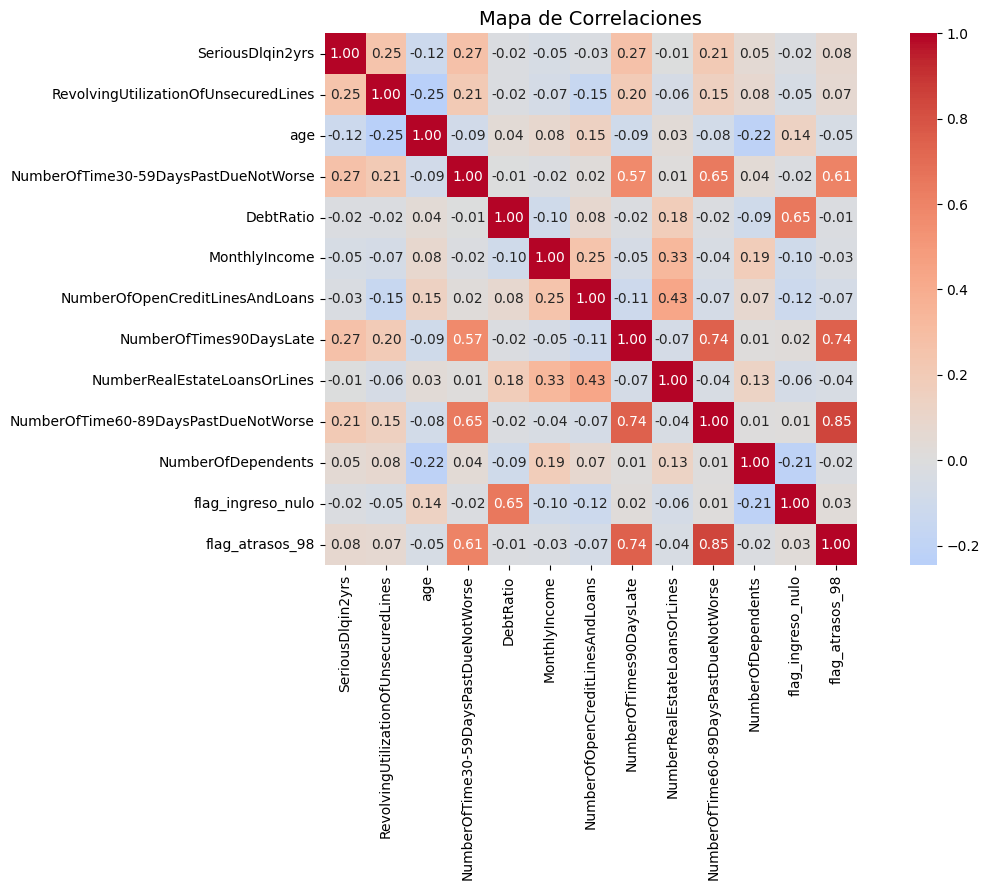


Correlación con SeriousDlqin2yrs:
SeriousDlqin2yrs                        1.000
NumberOfTimes90DaysLate                 0.269
NumberOfTime30-59DaysPastDueNotWorse    0.265
RevolvingUtilizationOfUnsecuredLines    0.251
NumberOfTime60-89DaysPastDueNotWorse    0.207
flag_atrasos_98                         0.080
NumberOfDependents                      0.047
NumberRealEstateLoansOrLines           -0.007
DebtRatio                              -0.017
flag_ingreso_nulo                      -0.021
NumberOfOpenCreditLinesAndLoans        -0.030
MonthlyIncome                          -0.050
age                                    -0.115
Name: SeriousDlqin2yrs, dtype: float64


In [10]:
########################################################
## MAPA DE CORRELACIONES                             ##
########################################################

plt.figure(figsize=(13, 9))
correlaciones = train.corr()

sns.heatmap(correlaciones,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)

plt.title('Mapa de Correlaciones', fontsize=14)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo ordenadas
print("\nCorrelación con SeriousDlqin2yrs:")
print(correlaciones['SeriousDlqin2yrs'].sort_values(ascending=False).round(3))

Del análisis de correlaciones se pueden extraer las siguientes conclusiones:

- Las **variables de atrasos** (30-59, 60-89, 90+ días) son las más correlacionadas con el incumplimiento. Sin embargo, también tienen una correlación alta entre sí (entre 0.58 y 0.75), lo que indica **multicolinealidad**. Para evitar redundancia, se excluye `NumberOfTime60-89DaysPastDueNotWorse` del modelo, conservando las otras dos.

- **RevolvingUtilizationOfUnsecuredLines** tiene la correlación individual más alta con el target, lo que confirma que el nivel de uso del crédito es un predictor muy relevante.

- **age** tiene correlación negativa: a mayor edad, menor riesgo de incumplimiento.

- **DebtRatio**, **NumberOfOpenCreditLinesAndLoans** y **NumberRealEstateLoansOrLines** presentan correlaciones bajas con el target, pero se conservan ya que aportan contexto financiero.

- Las variables indicadoras creadas en el preprocesamiento (`flag_ingreso_nulo`, `flag_atrasos_98`) se incluyen porque capturan información que de otro modo se perdería.

In [12]:
########################################################
## SELECCIÓN DE VARIABLES                            ##
########################################################

variables = [
    'RevolvingUtilizationOfUnsecuredLines',  # uso del crédito — más predictiva
    'age',                                   # edad — correlación negativa
    'NumberOfTime30-59DaysPastDueNotWorse',  # historial de atrasos leves
    'NumberOfTimes90DaysLate',               # historial de atrasos graves
    'DebtRatio',                             # nivel de endeudamiento
    'MonthlyIncome',                         # capacidad de pago
    'NumberOfOpenCreditLinesAndLoans',       # exposición crediticia
    'NumberRealEstateLoansOrLines',          # compromiso hipotecario
    'NumberOfDependents',                    # carga familiar
    'flag_ingreso_nulo',                     # señal: ingreso era desconocido
    'flag_atrasos_98'                        # señal: código especial de riesgo alto
]

X = train[variables]
y = train['SeriousDlqin2yrs']

print('Variables seleccionadas para modelado:')
for v in variables:
    print(f'  - {v}')
print(f'\nDimensiones de X: {X.shape}')
print(f'Dimensiones de y: {y.shape}')

Variables seleccionadas para modelado:
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - NumberOfTimes90DaysLate
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberRealEstateLoansOrLines
  - NumberOfDependents
  - flag_ingreso_nulo
  - flag_atrasos_98

Dimensiones de X: (150000, 11)
Dimensiones de y: (150000,)


Se excluyó la variable NumberOfTime60-89DaysPastDueNotWorse debido a su alta correlación con las otras dos variables relacionadas con atrasos en pagos (NumberOfTime30-59DaysPastDueNotWorse y NumberOfTimes90DaysLate), con coeficientes de correlación entre 0.58 y 0.75. Dado que estas variables capturan comportamientos muy similares, mantenerlas simultáneamente no aporta información adicional relevante y puede introducir problemas de multicolinealidad, afectando la estabilidad e interpretabilidad de modelos lineales como la Regresión Logística.

Adicionalmente, durante la etapa de preprocesamiento se incorporaron dos variables indicadoras que preservan información relevante identificada en el análisis exploratorio:

flag_ingreso_nulo: indica si el ingreso mensual (MonthlyIncome) estaba originalmente ausente, capturando la señal asociada a registros con ingreso desconocido.

flag_atrasos_98: identifica los registros que presentaban el código especial 98 en las variables de atraso, el cual corresponde a un grupo con mayor riesgo de incumplimiento dentro del conjunto de datos.

<a id="4-modelos"></a>
## 4. Implementación de Modelos

### 4.1 Preparación de datos para modelado

Separamos las variables predictoras (`X`) de la variable objetivo (`y`) y dividimos el conjunto de entrenamiento en dos partes:

- **X_train / y_train (80%):** datos con los que el modelo aprende.
- **X_val / y_val (20%):** datos que reservamos para evaluar qué tan bien generaliza el modelo antes de tocarlo con el conjunto de test.

Se usa `stratify=y` para garantizar que la proporción de defaults (6.7%) se mantenga igual en ambas partes del split, lo cual es fundamental cuando las clases están tan desbalanceadas.

In [14]:
########################################################
## SPLIT TRAIN / VALIDACIÓN                          ##
########################################################

# Variables predictoras y objetivo
X = train[variables].copy()
y = train['SeriousDlqin2yrs'].copy()

# Conjunto de test (ya fue imputado y tratado en la Sección 3)
X_test = test[variables].copy()

# División interna: 80% entrenamiento, 20% validación
# stratify=y asegura la misma proporción de defaults en ambas partes
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print('Dimensiones del split:')
print(f'  X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}   | y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'\nProporción de defaults en y_train: {y_train.mean()*100:.2f}%')
print(f'Proporción de defaults en y_val:   {y_val.mean()*100:.2f}%')

Dimensiones del split:
  X_train: (120000, 11) | y_train: (120000,)
  X_val:   (30000, 11)   | y_val:   (30000,)
  X_test:  (101503, 11)

Proporción de defaults en y_train: 6.68%
Proporción de defaults en y_val:   6.68%


### 4.2 k-Vecinos más cercanos (k-NN)

El algoritmo k-NN clasifica cada observación según las clases de sus `k` vecinos más cercanos. Como se basa en **distancias**, el escalamiento de las variables es fundamental: una variable con valores grandes dominaría el cálculo de distancia sobre las demás.

En esta sección evaluamos el impacto de dos tipos de escalamiento, tal como se vio en clase:

- **MinMaxScaler (Normalización):** transforma cada variable al rango [0, 1].
- **StandardScaler (Estandarización):** transforma cada variable para que tenga media 0 y desviación estándar 1.

En ambos casos el escalador se **ajusta solo con X_train** y se aplica a X_val, para no filtrar información del conjunto de validación al modelo.

In [15]:
########################################################
## k-NN CON NORMALIZACIÓN (MinMaxScaler)             ##
########################################################

resultados_modelos = []

# Escalar
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_val_minmax   = scaler_minmax.transform(X_val)

# Entrenar modelo base con k=5
knn_minmax = KNeighborsClassifier(n_neighbors=5)
knn_minmax.fit(X_train_minmax, y_train)

# Predicciones
pred_knn_minmax = knn_minmax.predict(X_val_minmax)

# Resultados
print("===== k-NN con Normalización (MinMaxScaler) =====")
print(classification_report(y_val, pred_knn_minmax))
print("Matriz de confusión:")
print(confusion_matrix(y_val, pred_knn_minmax))

# Guardar F1 de clase 1 (default) para comparar modelos
from sklearn.metrics import f1_score
f1_knn_minmax = f1_score(y_val, pred_knn_minmax)
resultados_modelos.append({
    "Modelo":        "k-NN (MinMaxScaler)",
    "F1 (default)":  round(f1_knn_minmax, 4)
})

===== k-NN con Normalización (MinMaxScaler) =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     27995
           1       0.47      0.17      0.25      2005

    accuracy                           0.93     30000
   macro avg       0.71      0.58      0.61     30000
weighted avg       0.91      0.93      0.92     30000

Matriz de confusión:
[[27601   394]
 [ 1655   350]]


In [16]:
########################################################
## k-NN CON ESTANDARIZACIÓN (StandardScaler)         ##
########################################################

# Escalar
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_val_std   = scaler_std.transform(X_val)

# Entrenar modelo base con k=5
knn_std = KNeighborsClassifier(n_neighbors=5)
knn_std.fit(X_train_std, y_train)

# Predicciones
pred_knn_std = knn_std.predict(X_val_std)

# Resultados
print("===== k-NN con Estandarización (StandardScaler) =====")
print(classification_report(y_val, pred_knn_std))
print("Matriz de confusión:")
print(confusion_matrix(y_val, pred_knn_std))

# Guardar F1 de clase 1 para comparar
f1_knn_std = f1_score(y_val, pred_knn_std)
resultados_modelos.append({
    "Modelo":        "k-NN (StandardScaler)",
    "F1 (default)":  round(f1_knn_std, 4)
})

===== k-NN con Estandarización (StandardScaler) =====
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     27995
           1       0.45      0.18      0.26      2005

    accuracy                           0.93     30000
   macro avg       0.70      0.58      0.61     30000
weighted avg       0.91      0.93      0.92     30000

Matriz de confusión:
[[27554   441]
 [ 1644   361]]


### 4.3 Regresión Logística

La Regresión Logística estima la **probabilidad** de que una observación pertenezca a la clase 1 (default). A diferencia de k-NN, genera un modelo explícito con coeficientes que permiten interpretar el peso de cada variable.

También evaluamos los dos tipos de escalamiento para comparar su efecto, reutilizando los mismos `X_train_std`, `X_val_std`, `X_train_minmax` y `X_val_minmax` calculados en la sección anterior.

In [17]:
########################################################
## REGRESIÓN LOGÍSTICA CON ESTANDARIZACIÓN           ##
########################################################

log_std = LogisticRegression(max_iter=50000, random_state=123)
log_std.fit(X_train_std, y_train)

pred_log_std = log_std.predict(X_val_std)

print("===== Regresión Logística con Estandarización =====")
print(classification_report(y_val, pred_log_std))
print("Matriz de confusión:")
print(confusion_matrix(y_val, pred_log_std))

f1_log_std = f1_score(y_val, pred_log_std)
resultados_modelos.append({
    "Modelo":        "Regresión Logística (StandardScaler)",
    "F1 (default)":  round(f1_log_std, 4)
})

===== Regresión Logística con Estandarización =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.56      0.14      0.23      2005

    accuracy                           0.94     30000
   macro avg       0.75      0.57      0.60     30000
weighted avg       0.92      0.94      0.92     30000

Matriz de confusión:
[[27776   219]
 [ 1721   284]]


In [18]:
########################################################
## REGRESIÓN LOGÍSTICA CON NORMALIZACIÓN             ##
########################################################

log_minmax = LogisticRegression(max_iter=50000, random_state=123)
log_minmax.fit(X_train_minmax, y_train)

pred_log_minmax = log_minmax.predict(X_val_minmax)

print("===== Regresión Logística con Normalización =====")
print(classification_report(y_val, pred_log_minmax))
print("Matriz de confusión:")
print(confusion_matrix(y_val, pred_log_minmax))

f1_log_minmax = f1_score(y_val, pred_log_minmax)
resultados_modelos.append({
    "Modelo":        "Regresión Logística (MinMaxScaler)",
    "F1 (default)":  round(f1_log_minmax, 4)
})

===== Regresión Logística con Normalización =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.56      0.13      0.21      2005

    accuracy                           0.93     30000
   macro avg       0.75      0.56      0.59     30000
weighted avg       0.92      0.93      0.92     30000

Matriz de confusión:
[[27793   202]
 [ 1750   255]]


### 4.4 Comparación inicial de modelos

Comparamos los cuatro modelos entrenados usando el **F1-Score de la clase 1 (default)** como métrica principal. Esta métrica es la más adecuada aquí porque combina precisión y recall, y no se ve distorsionada por el desbalanceo de clases como sí ocurre con el accuracy.

Esta comparación es solo un punto de partida — en la siguiente sección optimizaremos los hiperparámetros con Grid Search para mejorar estos resultados.

In [19]:
########################################################
## TABLA COMPARATIVA — MODELOS BASE                  ##
########################################################

tabla_resultados = pd.DataFrame(resultados_modelos)
tabla_resultados = tabla_resultados.sort_values('F1 (default)', ascending=False)
tabla_resultados = tabla_resultados.reset_index(drop=True)

print('Comparación inicial de modelos (conjunto de validación):')
print(tabla_resultados.to_string(index=False))

Comparación inicial de modelos (conjunto de validación):
                              Modelo  F1 (default)
               k-NN (StandardScaler)        0.2572
                 k-NN (MinMaxScaler)        0.2546
Regresión Logística (StandardScaler)        0.2265
  Regresión Logística (MinMaxScaler)        0.2071


De acuerdo con la comparación inicial de los modelos utilizando el F1-score, el modelo que presenta el mejor desempeño es **k-Nearest Neighbors (k-NN) con StandardScaler**, alcanzando un F1-score de 0.2572. Este resultado sugiere que el modelo logra un mejor equilibrio entre precisión y recall en la identificación de clientes en incumplimiento. Este comportamiento puede explicarse porque k-NN es un método no paramétrico que captura relaciones locales y potencialmente no lineales entre las variables, lo cual puede resultar ventajoso en problemas de riesgo crediticio donde los patrones de incumplimiento suelen depender de combinaciones específicas de características financieras de los clientes.

<a id="5-optimización"></a>
## 5. Optimización de Hiperparámetros y Validación

En la sección anterior entrenamos modelos base con hiperparámetros fijos (`k=5`, `C=1`). En esta sección buscamos la **mejor combinación de hiperparámetros** para cada modelo usando dos herramientas vistas en clase:

- **StratifiedKFold (Validación Cruzada Estratificada):** divide los datos en 5 pliegues asegurando que cada uno mantenga la misma proporción de defaults. Así el resultado no depende de un único split sino del promedio de 5 evaluaciones diferentes.

- **GridSearchCV (Búsqueda en Grilla):** prueba todas las combinaciones posibles de hiperparámetros dentro de la grilla definida y se queda con la que produce el mejor resultado.

Usamos `scoring="f1"` como métrica de optimización porque, dado el fuerte desbalanceo de clases, el F1-Score de la clase 1 (default) es el indicador más honesto del desempeño real del modelo.

### 5.1 Grid Search para k-NN

Usamos un `Pipeline` que combina el escalador y el modelo en un solo objeto. Esto permite incluir el **tipo de escalamiento** (MinMax vs Standard) como un hiperparámetro más dentro de la grilla, y garantiza que el escalador se ajuste solo con los datos de entrenamiento en cada pliegue de la validación cruzada.

La grilla explora las siguientes combinaciones:

- **Escalador:** StandardScaler o MinMaxScaler
- **Número de vecinos k:** 5, 10, 15, 20
- **Pesos:** uniform (todos los vecinos pesan igual) o distance (vecinos más cercanos pesan más)
- **Métrica de distancia:** euclidiana o manhattan

In [20]:
########################################################
## GRID SEARCH — k-NN                                ##
########################################################

# Estrategia de validación cruzada estratificada (5 pliegues)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Pipeline: escalador + modelo en un solo objeto
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier())
])

# Grilla de hiperparámetros a explorar
param_grid_knn = {
    "scaler":           [StandardScaler(), MinMaxScaler()],
    "knn__n_neighbors": [5, 10, 15, 20],
    "knn__weights":     ["uniform", "distance"],
    "knn__metric":      ["euclidean", "manhattan"]
}

# Búsqueda en grilla con validación cruzada estratificada
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring="f1",       # optimizamos F1 de clase 1 (default)
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train, y_train)

print("Mejores hiperparámetros k-NN:")
print(grid_knn.best_params_)
print(f"\nMejor F1 medio (CV): {grid_knn.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores hiperparámetros k-NN:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'distance', 'scaler': StandardScaler()}

Mejor F1 medio (CV): 0.2708


Revisamos las 10 mejores combinaciones de hiperparámetros encontradas para entender qué configuraciones funcionan mejor:

In [21]:
########################################################
## TOP 10 — RESULTADOS GRID SEARCH k-NN              ##
########################################################

resultados_knn_cv = (
    pd.DataFrame(grid_knn.cv_results_)
    .sort_values("mean_test_score", ascending=False)
    [["params", "mean_test_score", "std_test_score"]]
    .rename(columns={
        "mean_test_score": "F1 medio (CV)",
        "std_test_score":  "Desviación"
    })
    .head(10)
    .reset_index(drop=True)
)
resultados_knn_cv

,params,F1 medio (CV),Desviación
0,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.270784,0.008473
1,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.268410,0.005603
2,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.268231,0.008922
3,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.262140,0.008468
4,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.253274,0.008177
5,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.253204,0.013568
6,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.251935,0.013128
7,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.248885,0.009441
8,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.247017,0.008211
9,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.246639,0.007040


Los resultados del Grid Search con validación cruzada de 5 folds muestran que la mejor configuración del modelo k-NN utiliza distancia euclidiana, 5 vecinos y ponderación por distancia, junto con StandardScaler para el escalamiento de las variables. Esta combinación alcanza un F1-score medio de 0.2708, mejorando el desempeño del modelo base. Además, la baja desviación observada entre los folds indica que el modelo presenta un comportamiento estable y consistente durante la validación cruzada.

### 5.2 Grid Search para Regresión Logística

Para la Regresión Logística optimizamos los siguientes hiperparámetros:

- **C (regularización):** controla qué tan flexible es el modelo. Un C pequeño (0.01, 0.1) impone más restricciones y produce un modelo más simple. Un C grande (10, 100) da más libertad al modelo pero puede sobreajustarse.

- **class_weight:** permite indicarle al modelo que penalice más los errores en la clase minoritaria (default). Con `"balanced"` el modelo ajusta automáticamente los pesos según la proporción de cada clase — útil con datos desbalanceados.

Cabe destacar que, se utilizó únicamente StandardScaler para el escalamiento de las variables. Esto se debe a que, en la comparación inicial de los modelos base, la versión del modelo que empleaba StandardScaler presentó un desempeño ligeramente superior frente a otras configuraciones. Además, a diferencia de k-NN, la Regresión Logística no depende directamente de distancias entre observaciones, por lo que no es tan sensible al tipo específico de normalización. Por esta razón, se optó por mantener StandardScaler como único método de escalamiento durante el proceso de Grid Search, concentrando la optimización en los hiperparámetros propios del modelo, como C (regularización) y class_weight.

In [22]:
########################################################
## GRID SEARCH — REGRESIÓN LOGÍSTICA                 ##
########################################################

# Pipeline: escalador + modelo
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=50000, random_state=123))
])

# Grilla de hiperparámetros
param_grid_log = {
    "logreg__C":            [0.01, 0.1, 1.0, 10.0],
    "logreg__class_weight": [None, "balanced"]
}

# Búsqueda en grilla con validación cruzada estratificada
grid_log = GridSearchCV(
    estimator=pipe_log,
    param_grid=param_grid_log,
    scoring="f1",       # optimizamos F1 de clase 1 (default)
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_log.fit(X_train, y_train)

print("Mejores hiperparámetros Regresión Logística:")
print(grid_log.best_params_)
print(f"\nMejor F1 medio (CV): {grid_log.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores hiperparámetros Regresión Logística:
{'logreg__C': 10.0, 'logreg__class_weight': 'balanced'}

Mejor F1 medio (CV): 0.3298


Revisamos las 10 mejores combinaciones para la Regresión Logística:

In [23]:
########################################################
## TOP 10 — RESULTADOS GRID SEARCH REGRESIÓN LOG.    ##
########################################################

resultados_log_cv = (
    pd.DataFrame(grid_log.cv_results_)
    .sort_values("mean_test_score", ascending=False)
    [["params", "mean_test_score", "std_test_score"]]
    .rename(columns={
        "mean_test_score": "F1 medio (CV)",
        "std_test_score":  "Desviación"
    })
    .head(10)
    .reset_index(drop=True)
)
resultados_log_cv

,params,F1 medio (CV),Desviación
0,"{'logreg__C': 10.0, 'logreg__class_weight': 'b...",0.329833,0.005935
1,"{'logreg__C': 1.0, 'logreg__class_weight': 'ba...",0.329788,0.005987
2,"{'logreg__C': 0.1, 'logreg__class_weight': 'ba...",0.329677,0.006026
3,"{'logreg__C': 0.01, 'logreg__class_weight': 'b...",0.329386,0.006251
4,"{'logreg__C': 1.0, 'logreg__class_weight': None}",0.228347,0.008450
5,"{'logreg__C': 10.0, 'logreg__class_weight': None}",0.228347,0.008450
6,"{'logreg__C': 0.1, 'logreg__class_weight': None}",0.228090,0.008815
7,"{'logreg__C': 0.01, 'logreg__class_weight': None}",0.224937,0.008908


Los resultados del Grid Search para la Regresión Logística muestran que la mejor configuración corresponde a C = 10 y class_weight = "balanced", alcanzando un F1-score medio de 0.3298 en validación cruzada. El uso de class_weight="balanced" resulta especialmente útil en este problema debido al desbalance de clases, ya que asigna mayor penalización a los errores en la clase minoritaria (default). Además, la baja desviación entre folds indica que el modelo presenta un desempeño estable y consistente bajo diferentes particiones de los datos.

### 5.3 Comparación de modelos tras validación cruzada

Comparamos los **mejores modelos** de cada algoritmo según el F1 medio obtenido en la validación cruzada. El modelo con mayor F1 será el que usemos en la Sección 6 para la evaluación final.

In [24]:
########################################################
## COMPARACIÓN FINAL TRAS GRID SEARCH                ##
########################################################

resumen_cv = pd.DataFrame([
    {
        "Modelo":         "k-NN (mejor configuración CV)",
        "Mejores params": str(grid_knn.best_params_),
        "F1 medio (CV)":  round(grid_knn.best_score_, 4)
    },
    {
        "Modelo":         "Regresión Logística (mejor configuración CV)",
        "Mejores params": str(grid_log.best_params_),
        "F1 medio (CV)":  round(grid_log.best_score_, 4)
    }
])

print("Comparación de modelos — F1 medio en validación cruzada:")
resumen_cv

Comparación de modelos — F1 medio en validación cruzada:


,Modelo,Mejores params,F1 medio (CV)
0,k-NN (mejor configuración CV),"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.2708
1,Regresión Logística (mejor configuración CV),"{'logreg__C': 10.0, 'logreg__class_weight': 'b...",0.3298


Al comparar los modelos optimizados mediante validación cruzada, se observa que la Regresión Logística presenta un mejor desempeño que k-NN. En particular, la Regresión Logística alcanza un F1-score medio de 0.3298, mientras que k-NN obtiene 0.2708. Este resultado sugiere que, tras la optimización de hiperparámetros, la Regresión Logística logra un mejor equilibrio entre precisión y recall en la detección de clientes en incumplimiento, por lo que se perfila como el modelo más adecuado entre los evaluados en esta etapa.

<a id="6-métricas"></a>
## 6. Métricas de Evaluación y Decisión

En esta sección tomamos el **mejor modelo encontrado en la Sección 5** y lo evaluamos sobre el conjunto de validación `X_val` que fue reservado exclusivamente para esta etapa — el modelo nunca lo vio durante el entrenamiento.

Para evaluar el desempeño usamos:

- **Matriz de confusión:** muestra cuántos casos el modelo clasificó correctamente e incorrectamente para cada clase.
- **Reporte de clasificación:** resume las métricas de Accuracy, Precisión, Recall y F1-Score para cada clase.

### 6.1 Evaluación del modelo final

Comparamos los dos mejores modelos obtenidos por Grid Search — k-NN y Regresión Logística — evaluándolos sobre el conjunto de validación.

Recordemos el significado de cada métrica en el contexto de riesgo crediticio:

- **Accuracy:** porcentaje total de predicciones correctas. Con datos desbalanceados puede ser engañosa — un modelo que nunca predice default tendría 93% de accuracy sin detectar ningún caso de riesgo.
- **Precisión (clase 1):** de todos los que el modelo marcó como "default", ¿qué proporción realmente incumplió?
- **Recall (clase 1):** de todos los que realmente incumplieron, ¿qué proporción detectó el modelo? Esta métrica es crítica en riesgo crediticio porque un Falso Negativo (no detectar a alguien que va a incumplir) es más costoso que un Falso Positivo.
- **F1-Score (clase 1):** promedio armónico entre precisión y recall. Es la métrica principal para comparar modelos con clases desbalanceadas.

In [25]:
########################################################
## EVALUACIÓN — MEJOR MODELO k-NN                   ##
########################################################

# Recuperar el mejor modelo k-NN y evaluarlo en validación
mejor_knn = grid_knn.best_estimator_
mejor_knn.fit(X_train, y_train)
pred_val_knn = mejor_knn.predict(X_val)

print("===== Mejor k-NN (Grid Search) — Conjunto de Validación =====")
print(classification_report(y_val, pred_val_knn))

===== Mejor k-NN (Grid Search) — Conjunto de Validación =====
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     27995
           1       0.43      0.19      0.26      2005

    accuracy                           0.93     30000
   macro avg       0.69      0.59      0.61     30000
weighted avg       0.91      0.93      0.92     30000



El modelo k-NN presenta un F1-score de 0.26 para la clase 1, con precision de 0.43 y recall de 0.19. Esto indica que, aunque cuando predice default suele acertar con relativa frecuencia, el modelo detecta solo una pequeña proporción de los incumplimientos reales, lo que limita su utilidad en un contexto de riesgo crediticio.

In [26]:
########################################################
## EVALUACIÓN — MEJOR MODELO REGRESIÓN LOGÍSTICA    ##
########################################################

# Recuperar el mejor modelo de Regresión Logística y evaluarlo en validación
mejor_log = grid_log.best_estimator_
mejor_log.fit(X_train, y_train)
pred_val_log = mejor_log.predict(X_val)

print("===== Mejor Regresión Logística (Grid Search) — Conjunto de Validación =====")
print(classification_report(y_val, pred_val_log))

===== Mejor Regresión Logística (Grid Search) — Conjunto de Validación =====
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.73      0.33      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.77      0.61     30000
weighted avg       0.93      0.80      0.85     30000



Por su parte, la Regresión Logística obtiene un F1-score de 0.33 para la clase 1, superando al modelo k-NN. En particular, destaca un recall de 0.73, lo que significa que el modelo logra identificar una mayor proporción de clientes que realmente incumplen. Aunque la precision es menor (0.22), este comportamiento es común en problemas desbalanceados donde el objetivo principal es no dejar pasar casos de alto riesgo.

En conjunto, estos resultados sugieren que la Regresión Logística ofrece un mejor equilibrio entre precisión y recall, especialmente al priorizar la detección de incumplimientos, por lo que se perfila como el modelo más adecuado para este problema de riesgo crediticio.

### 6.2 Matrices de confusión

La matriz de confusión muestra en detalle los cuatro tipos de resultado posibles:

- **Verdadero Negativo (TN):** predijo "no default" y era correcto.
- **Falso Positivo (FP):** predijo "default" pero no lo era. *(El banco rechaza a un cliente que habría pagado)*
- **Falso Negativo (FN):** predijo "no default" pero sí incumplió. *(El banco aprueba a alguien que no va a pagar — el error más costoso)*
- **Verdadero Positivo (TP):** predijo "default" y era correcto.

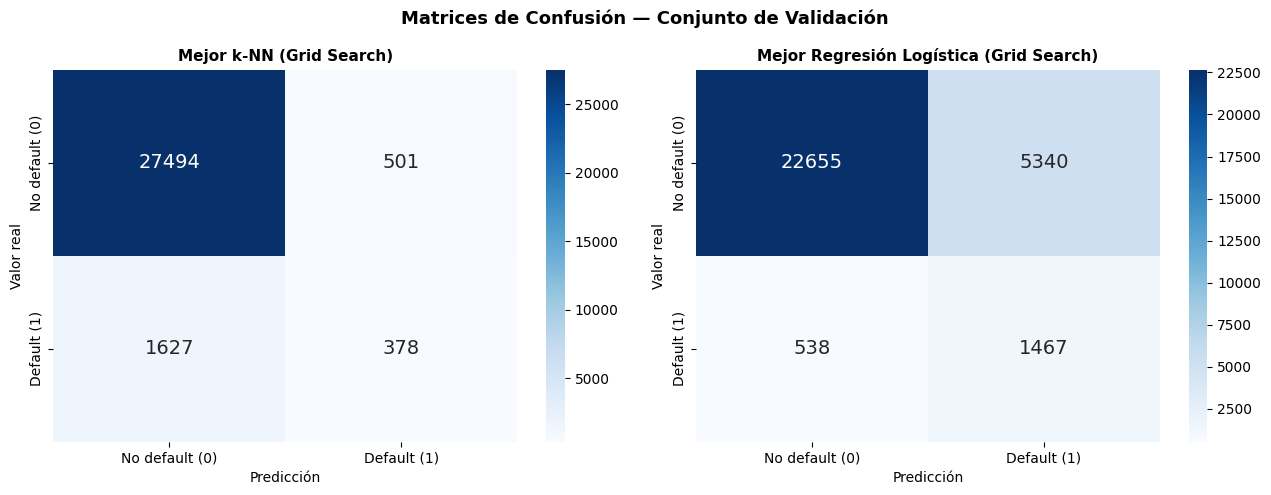

In [27]:
########################################################
## MATRICES DE CONFUSIÓN — AMBOS MODELOS            ##
########################################################

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

modelos_eval = [
    (pred_val_knn, "Mejor k-NN (Grid Search)"),
    (pred_val_log, "Mejor Regresión Logística (Grid Search)")
]

for ax, (pred, titulo) in zip(axes, modelos_eval):
    mc = confusion_matrix(y_val, pred)
    sns.heatmap(
        mc,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        annot_kws={"size": 14},
        xticklabels=["No default (0)", "Default (1)"],
        yticklabels=["No default (0)", "Default (1)"]
    )
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicción", fontsize=10)
    ax.set_ylabel("Valor real", fontsize=10)

plt.suptitle("Matrices de Confusión — Conjunto de Validación",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Las matrices de confusión permiten comparar cómo se comportan los modelos al clasificar correctamente los casos de default y no default. En el caso de k-NN, el modelo clasifica correctamente 27 494 casos de no incumplimiento, pero solo identifica 378 de los 2 005 casos reales de default, lo que refleja una baja capacidad para detectar la clase minoritaria. Por otro lado, la Regresión Logística identifica 1 467 casos de default, una mejora sustancial frente a k-NN, aunque a costa de un mayor número de falsos positivos (clientes clasificados como default cuando no lo son). En problemas de riesgo crediticio, este comportamiento suele ser preferible, ya que es más costoso no detectar un cliente riesgoso (falso negativo) que generar una alerta adicional, lo que refuerza la elección de la Regresión Logística como modelo final.

### 6.3 Decisión del modelo final

Con base en las métricas de validación cruzada (Sección 5) y la evaluación sobre el conjunto de validación (Sección 6), seleccionamos el modelo con mejor F1-Score en la clase 1 como **modelo final**.

En el contexto de riesgo crediticio priorizamos el **Recall de la clase 1**: es preferible ser más cauteloso y señalar algunos falsos positivos que dejar pasar clientes que van a incumplir (falsos negativos).

In [28]:
########################################################
## TABLA COMPARATIVA FINAL                          ##
########################################################

from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

comparacion_final = pd.DataFrame([
    {
        "Modelo":              "k-NN (mejor Grid Search)",
        "Accuracy":            round(accuracy_score(y_val, pred_val_knn), 4),
        "Precisión (default)": round(precision_score(y_val, pred_val_knn), 4),
        "Recall (default)":    round(recall_score(y_val, pred_val_knn), 4),
        "F1 (default)":        round(f1_score(y_val, pred_val_knn), 4)
    },
    {
        "Modelo":              "Regresión Logística (mejor Grid Search)",
        "Accuracy":            round(accuracy_score(y_val, pred_val_log), 4),
        "Precisión (default)": round(precision_score(y_val, pred_val_log), 4),
        "Recall (default)":    round(recall_score(y_val, pred_val_log), 4),
        "F1 (default)":        round(f1_score(y_val, pred_val_log), 4)
    }
])

print("Comparación final de modelos — Conjunto de Validación:")
comparacion_final

Comparación final de modelos — Conjunto de Validación:


,Modelo,Accuracy,Precisión (default),Recall (default),F1 (default)
0,k-NN (mejor Grid Search),0.9291,0.4300,0.1885,0.2621
1,Regresión Logística (mejor Grid Search),0.8041,0.2155,0.7317,0.3330


La comparación final de los modelos muestra que k-NN alcanza una mayor accuracy (0.9291) y precisión (0.43) para la clase default, pero presenta un recall muy bajo (0.1885), lo que indica que detecta solo una pequeña proporción de los clientes que realmente incumplen. En contraste, la Regresión Logística logra un recall significativamente mayor (0.7317), identificando la mayoría de los casos de incumplimiento, aunque con una precisión menor (0.2155) y una accuracy más baja (0.8041). Como consecuencia, la Regresión Logística obtiene también el mayor F1-score (0.3330) para la clase default.

**En el contexto de riesgo crediticio, donde es más costoso no detectar un cliente que va a incumplir que generar algunos falsos positivos, resulta preferible un modelo con mayor recall en la clase de default. Por esta razón, se selecciona la Regresión Logística como modelo final.**

<a id="7-test"></a>
## 7. Predicción en el conjunto de test

Antes de generar las predicciones finales, se realiza una inspección del conjunto de test (X_test) para verificar que las variables tengan la misma estructura que el conjunto utilizado para entrenar el modelo. En esta etapa se confirma que la base ya incorpora todas las transformaciones aplicadas en el preprocesamiento, incluyendo la imputación de valores faltantes, el tratamiento de outliers y la creación de nuevas variables derivadas como flag_ingreso_nulo y flag_atrasos_98. De esta manera, el conjunto de test mantiene exactamente las mismas variables y transformaciones que el conjunto de entrenamiento, garantizando que el modelo pueda aplicar correctamente las predicciones sobre datos preparados bajo el mismo esquema de procesamiento.

In [36]:
X_test.describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,flag_ingreso_nulo,flag_atrasos_98
count,101503.000000,101503.000000,101503.000000,101503.000000,101503.000000,101503.000000,101503.000000,101503.000000,101503.00000,101503.000000,101503.000000
mean,0.330565,52.404599,0.274524,0.117386,314.010870,6139.879521,8.453514,1.013074,0.74915,0.198053,0.002098
std,0.407885,14.777235,0.915546,0.758526,903.964523,3819.079148,5.144100,1.110253,1.12860,0.398534,0.045761
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.030131,41.000000,0.000000,0.000000,0.173423,3900.000000,5.000000,0.000000,0.00000,0.000000,0.000000
50%,0.152586,52.000000,0.000000,0.000000,0.364260,5400.000000,8.000000,1.000000,0.00000,0.000000,0.000000
75%,0.564225,63.000000,0.000000,0.000000,0.851619,7374.000000,11.000000,2.000000,1.00000,0.000000,0.000000
max,5.000000,95.000000,13.000000,13.000000,4979.040000,23000.000000,85.000000,37.000000,43.00000,1.000000,1.000000


In [29]:
########################################################
## ENTRENAMIENTO FINAL CON TODOS LOS DATOS           ##
########################################################

# Seleccionar el mejor modelo según los resultados de la Sección 6
# (reemplazar grid_log por grid_knn si k-NN obtuvo mejor F1)
modelo_final = grid_log.best_estimator_

# Entrenar con todo X (no solo X_train) para maximizar la información
modelo_final.fit(X, y)

# Generar probabilidades de default para el conjunto de test
proba_test = modelo_final.predict_proba(X_test)[:, 1]

print(f"Predicciones generadas: {len(proba_test)}")
print(f"Probabilidad mínima:    {proba_test.min():.4f}")
print(f"Probabilidad máxima:    {proba_test.max():.4f}")
print(f"Probabilidad media:     {proba_test.mean():.4f}")

Predicciones generadas: 101503
Probabilidad mínima:    0.0364
Probabilidad máxima:    1.0000
Probabilidad media:     0.3480


El modelo generó probabilidades de incumplimiento para 101 503 observaciones, lo cual coincide con el tamaño del conjunto de test. Esto confirma que se produjo una predicción para cada registro disponible.

- **Probabilidad mínima: ** La probabilidad mínima estimada es 0.0364, lo que indica que incluso los clientes considerados de menor riesgo mantienen una probabilidad positiva de incumplimiento. Esto es esperable en modelos de riesgo crediticio, donde raramente se asignan probabilidades cercanas a cero absoluto.

- **Probabilidad máxima:** La probabilidad máxima es 1.0000, lo que significa que el modelo identifica al menos un caso con un perfil extremadamente riesgoso.

- **Probabilidad media.:** La probabilidad media estimada es 0.3480, lo que sugiere que, en promedio, el modelo asigna una probabilidad de incumplimiento cercana al 35 % en el conjunto de test. Este valor es mayor al porcentaje real de default observado en el entrenamiento, lo cual es coherente con el uso de class_weight="balanced", que aumenta la sensibilidad del modelo hacia la clase minoritaria.

In [38]:
# Convertir probabilidades a clases usando umbral 0.5
pred_test = (proba_test >= 0.5).astype(int)
conteo = pd.Series(pred_test).value_counts().sort_index()

print("Distribución de predicciones en test:")
print(f"No default (0): {conteo.get(0,0)}")
print(f"Default (1): {conteo.get(1,0)}")


Distribución de predicciones en test:
No default (0): 77986
Default (1): 23517


In [39]:
print("\nPorcentaje:")
print(pd.Series(pred_test).value_counts(normalize=True).sort_index())


Porcentaje:
0    0.768312
1    0.231688
Name: proportion, dtype: float64


Al convertir las probabilidades a clases utilizando un umbral de 0.5, el modelo clasifica 77 986 observaciones como no default (0) y 23 517 como default (1). En términos porcentuales, el modelo predice 76.8 % de clientes como no default y 23.2 % como default. Esta distribución refleja un modelo relativamente conservador, que prioriza identificar posibles incumplimientos incluso a costa de generar algunos falsos positivos, lo cual es una estrategia común en problemas de evaluación de riesgo crediticio.

<a id="8. Conclusiones"></a>
## 8. Conclusiones

